# Challenge 5 — K-Means Clustering

## Public Health & Epidemiology

This notebook implements the K-Means clustering algorithm on the preprocessed BRFSS dataset.

The objective is to discover latent population health profiles using unsupervised learning techniques. K-Means partitions the dataset into groups of individuals with similar behavioral, demographic, and health-related characteristics.

The analysis includes:

- Hyperparameter selection using the Elbow Method
- Silhouette score analysis
- Cluster evaluation metrics
- PCA-based visualizations
- Cluster interpretation

# K-MEANS CLUSTERING

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Data Loading

The preprocessing pipeline generated two datasets:

- `X_processed`: fully processed feature matrix
- `X_pca`: PCA-reduced representation retaining 90% variance

K-Means will initially be applied on the PCA representation to reduce noise and improve clustering stability.

In [2]:

X_processed = np.load("../results/X_processed.npy")
X_pca = np.load("../results/X_pca.npy")

print("Processed shape:", X_processed.shape)
print("PCA shape:", X_pca.shape)

Processed shape: (29999, 51)
PCA shape: (29999, 20)


# Hyperparameter Selection — Elbow Method

K-Means requires defining the number of clusters `k` beforehand.

The Elbow Method evaluates the inertia (within-cluster sum of squares) across different values of `k`. The optimal value is typically located at the point where inertia reduction starts to diminish significantly.

This method helps identify a balance between cluster compactness and model complexity.

In [3]:
k_values = range(2, 13)

inertias = []

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=RANDOM_STATE
    )
    
    kmeans.fit(X_pca)
    
    inertias.append(kmeans.inertia_)

print("Elbow analysis completed.")

Elbow analysis completed.


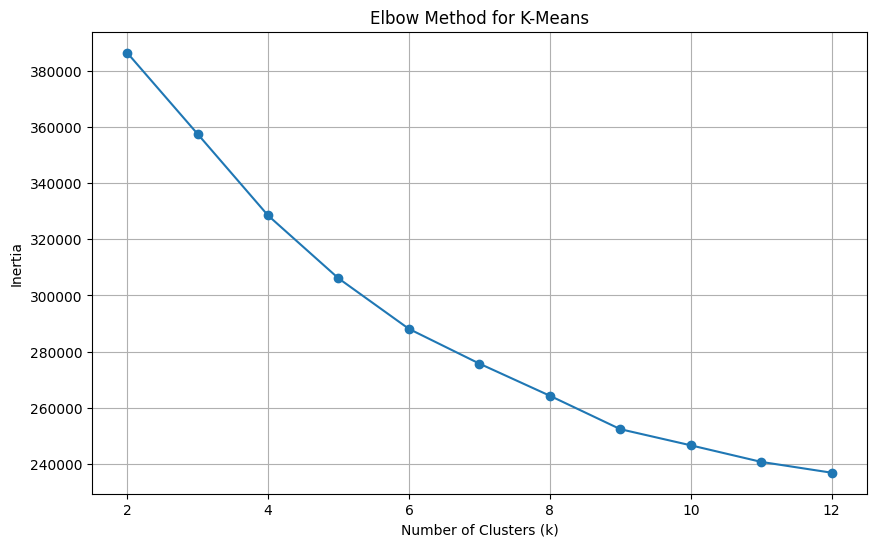

In [15]:
# =========================
# Elbow Curve
# =========================

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertias,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.grid(True)
plt.savefig('/home/sbuitrago/challenge5__3/figures/elbow_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Silhouette Analysis

The Silhouette Score evaluates both cluster cohesion and cluster separation.

A higher Silhouette Score indicates:
- compact clusters,
- good separation between clusters,
- and more meaningful clustering structure.

The score ranges from:
- `-1` → poor clustering
- `0` → overlapping clusters
- `1` → highly separated clusters

This analysis complements the Elbow Method and helps identify the most appropriate number of clusters.

In [5]:
# =========================
# Silhouette Analysis
# =========================

silhouette_scores = []

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=RANDOM_STATE
    )
    
    labels = kmeans.fit_predict(X_pca)
    
    score = silhouette_score(X_pca, labels)
    
    silhouette_scores.append(score)

print("Silhouette analysis completed.")

Silhouette analysis completed.


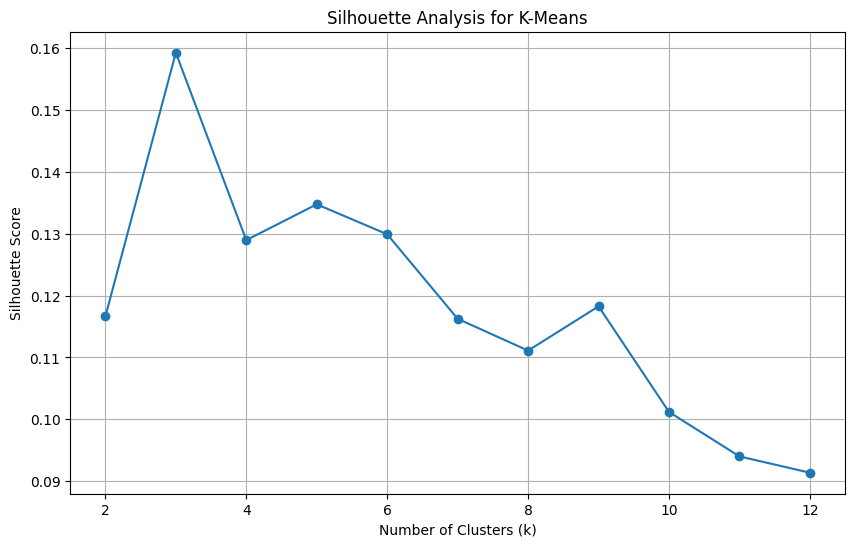

In [14]:
# =========================
# Silhouette Curve
# =========================

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for K-Means")

plt.grid(True)
plt.savefig('/home/sbuitrago/challenge5__3/figures/silhouette_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# =========================
# Show scores
# =========================

for k, score in zip(k_values, silhouette_scores):
    print(f"k = {k}: silhouette score = {score:.4f}")

k = 2: silhouette score = 0.1166
k = 3: silhouette score = 0.1592
k = 4: silhouette score = 0.1289
k = 5: silhouette score = 0.1347
k = 6: silhouette score = 0.1299
k = 7: silhouette score = 0.1162
k = 8: silhouette score = 0.1111
k = 9: silhouette score = 0.1183
k = 10: silhouette score = 0.1012
k = 11: silhouette score = 0.0940
k = 12: silhouette score = 0.0914


# Final K-Means Model

Based on the Elbow Method and Silhouette Analysis, the final K-Means configuration was selected with:

- `k = 3`
- `init = k-means++`
- `n_init = 10`
- `random_state = 42`

This configuration achieved the best balance between cluster compactness, separation, and interpretability.

In [8]:
# =========================
# Final K-Means Model
# =========================

BEST_K = 3

kmeans = KMeans(
    n_clusters=BEST_K,
    init='k-means++',
    n_init=10,
    random_state=RANDOM_STATE
)

kmeans_labels = kmeans.fit_predict(X_pca)

print("K-Means model trained successfully.")

K-Means model trained successfully.


In [9]:
# =========================
# Cluster distribution
# =========================

cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

print(cluster_counts)

0     2492
1    23893
2     3614
Name: count, dtype: int64


In [10]:
# =========================
# Evaluation Metrics
# =========================

silhouette = silhouette_score(X_pca, kmeans_labels)

davies_bouldin = davies_bouldin_score(
    X_pca,
    kmeans_labels
)

calinski_harabasz = calinski_harabasz_score(
    X_pca,
    kmeans_labels
)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")

Silhouette Score: 0.1592
Davies-Bouldin Index: 1.9164
Calinski-Harabasz Index: 2874.7400


# PCA Cluster Visualization

To visually inspect the clustering structure, the PCA-transformed dataset is projected onto the first two principal components.

Each point represents an individual respondent, colored according to its assigned cluster.

Although dimensionality reduction compresses the original feature space, these visualizations help assess cluster separation and overall structure.

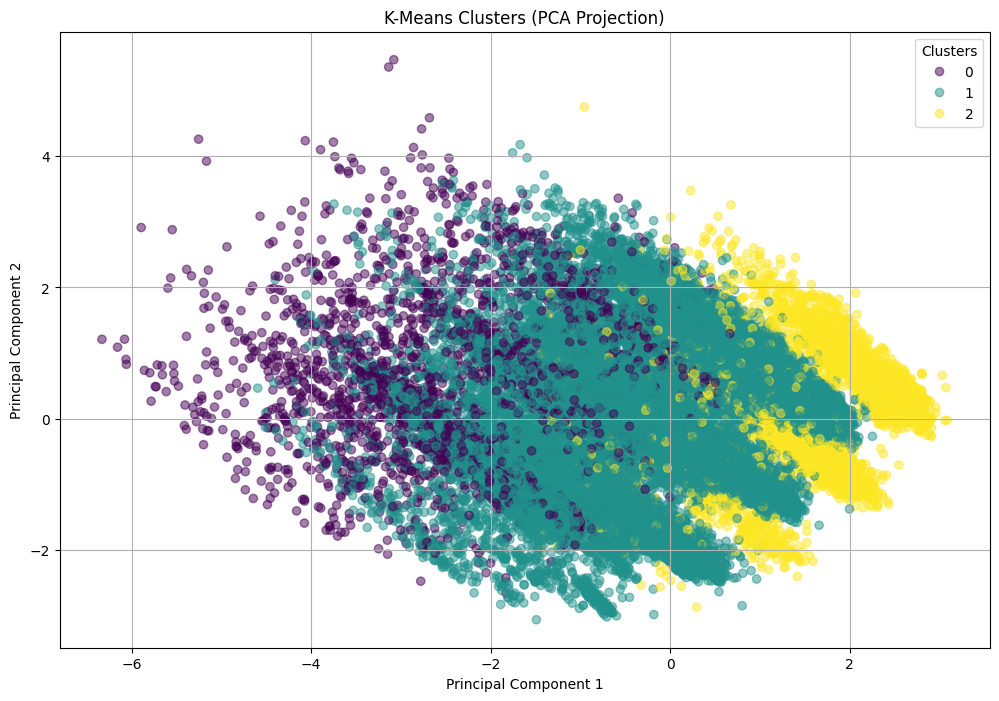

In [13]:
# =========================
# PCA Cluster Visualization
# =========================

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clusters (PCA Projection)")

plt.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

plt.grid(True)
plt.savefig('/home/sbuitrago/challenge5__3/figures/kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# =========================
# Save K-Means labels
# =========================

np.save(
    "../results/kmeans_labels.npy",
    kmeans_labels
)

joblib.dump(
    kmeans,
    "../results/kmeans_model.pkl"
)

print("K-Means artifacts saved successfully.")

K-Means artifacts saved successfully.
